# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Load the prepared dataset from Phase 3
DATA_PATH = 'path/to/your/prepared_data.csv'

# df = pd.read_csv(DATA_PATH)
# print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
# df.head()

---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [11]:
# Task 1: Documenting our modelling techniques
modelling_techniques = {
    "problem_type": "Binary Classification", 
    "target_variable": "target_risk",
    "candidate_models": [
        {
            "name": "Random Forest Classifier",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Excellent for handling complex, non-linear relationships in tabular data. It is robust against overfitting.",
            "assumptions": "Non-parametric. Does not assume normality or linearity."
        },
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Serves as a strong, interpretable baseline model to understand linear relationships.",
            "assumptions": "Assumes a linear relationship between log-odds and features; assumes minimal multicollinearity."
        },
        {
            "name": "Decision Tree Classifier",
            "library": "sklearn.tree.DecisionTreeClassifier",
            "justification": "Provides high interpretability and is useful for identifying critical decision points in student behavior. We use it to monitor potential overfitting scenarios.",
            "assumptions": "Non-parametric. No specific distribution assumptions for the features."
        },
        {
            "name": "XGBoost Classifier",
            "library": "xgboost.XGBClassifier",
            "justification": "A state-of-the-art boosting algorithm known for high performance and efficiency with structured data. It often yields the highest accuracy for classification tasks.",
            "assumptions": "Non-parametric. Handles missing values and outliers effectively without strict assumptions."
        }
    ]
}

# Display the selected techniques beautifully
print(f"📌 Problem Type: {modelling_techniques['problem_type']}")
print(f"🎯 Target Variable: {modelling_techniques['target_variable']}")
print(f"\n🚀 Candidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']}")
    print(f"     - Library: {model['library']}")
    print(f"     - Justification: {model['justification']}")
    print(f"     - Assumptions: {model['assumptions']}\n")

📌 Problem Type: Binary Classification
🎯 Target Variable: target_risk

🚀 Candidate Models:
  1. Random Forest Classifier
     - Library: sklearn.ensemble.RandomForestClassifier
     - Justification: Excellent for handling complex, non-linear relationships in tabular data. It is robust against overfitting.
     - Assumptions: Non-parametric. Does not assume normality or linearity.

  2. Logistic Regression
     - Library: sklearn.linear_model.LogisticRegression
     - Justification: Serves as a strong, interpretable baseline model to understand linear relationships.
     - Assumptions: Assumes a linear relationship between log-odds and features; assumes minimal multicollinearity.

  3. Decision Tree Classifier
     - Library: sklearn.tree.DecisionTreeClassifier
     - Justification: Provides high interpretability and is useful for identifying critical decision points in student behavior. We use it to monitor potential overfitting scenarios.
     - Assumptions: Non-parametric. No specific

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Essential modeling libraries imported successfully!")

✅ Essential modeling libraries imported successfully!


---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [12]:
# Task 2: Data Splitting
from sklearn.model_selection import train_test_split

# تحميل الداتا اللي سييفناها في Phase 3
df = pd.read_csv('final_data_ready_for_modeling.csv')

# فصل الـ Features عن الـ Target
X = df.drop(columns=['target_risk'])
y = df['target_risk']

# تقسيم الداتا 80% تدريب و 20% اختبار مع Stratify عشان نحافظ على نسبة الناجحين والساقطين
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Data split complete!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

✅ Data split complete!
Training set: 26074 samples
Test set: 6519 samples


In [13]:

test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Hold-out validation (Train/Test Split)",
    "stratified": True,
    "random_seed": RANDOM_SEED,
    "justification": "A standard 80/20 hold-out split is appropriate given our large dataset (32k+ records). We explicitly used 'stratified=y' to ensure that the proportion of at-risk students remains identical in both the training and testing sets, preventing a biased model. Prior to splitting, One-Hot Encoding was applied to convert categorical demographics into a machine-readable numeric format."
}


print("=== 📊 Test Design Documentation ===")
for key, value in test_design.items():
    print(f"• {key.replace('_', ' ').title()}: {value}")

=== 📊 Test Design Documentation ===
• Split Ratio: 80/20
• Validation Strategy: Hold-out validation (Train/Test Split)
• Stratified: True
• Random Seed: 42
• Justification: A standard 80/20 hold-out split is appropriate given our large dataset (32k+ records). We explicitly used 'stratified=y' to ensure that the proportion of at-risk students remains identical in both the training and testing sets, preventing a biased model. Prior to splitting, One-Hot Encoding was applied to convert categorical demographics into a machine-readable numeric format.


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [17]:
pip install xgboost 

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 3.3 MB/s eta 0:00:31
    --------------------------------------- 1.6/101.7 MB 3.5 MB/s eta 0:00:29
    --------------------------------------- 2.4/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 3.1/101.7 MB 3.5 MB/s eta 0:00:28
   - -------------------------------------- 3.9/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 4.7/101.7 MB 3.6 MB/s eta 0:00:28
   -- ------------------------------------- 5.5/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 6.0/101.7 MB 3.5 MB/s eta 0:00:27
   -- ------------------------------------- 6.8/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 7.6/101.7 MB 3.5 MB/s eta 0:00:27
   --- -

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# تعريف الموديلات
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=None), # سيبناه مفتوح عشان نشوف الـ Overfitting
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

trained_models = {}
# تنظيف أسماء الأعمدة عشان XGBoost مش بيحب الأقواس [ ] أو <
import re

# السطرين دول هيغيروا أي قوس أو علامة < لـ underscore (_)
X_train.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<]', '_', str(col)) for col in X_test.columns]

# دلوقتي كمل الكود بتاعك عادي
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
# تدريب كل الموديلات
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("✅ All 4 models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
✅ All 4 models trained successfully!


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [20]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

# هنلف على كل الموديلات اللي اتدربت ونحسب دقتها
for name, model in trained_models.items():
    # حساب الدقة في داتا التدريب (اللي الموديل شافها)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    
    # حساب الدقة في داتا الاختبار (اللي أول مرة الموديل يشوفها)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    results.append({
        "Model": name,
        "Training Accuracy": f"{train_acc:.2%}",
        "Testing Accuracy": f"{test_acc:.2%}",
        "Overfitting Gap": f"{(train_acc - test_acc):.2%}"
    })

# عرض النتائج في جدول شيك
comparison_df = pd.DataFrame(results)
print("=== 🎯 Model Comparison & Overfitting Check ===")
display(comparison_df)

=== 🎯 Model Comparison & Overfitting Check ===


,Model,Training Accuracy,Testing Accuracy,Overfitting Gap
0,Logistic Regression,68.08%,68.54%,-0.46%
1,Decision Tree,98.42%,61.90%,36.52%
2,Random Forest,72.85%,70.24%,2.61%
3,XGBoost,75.78%,69.69%,6.10%


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("=== 🎯 Model Evaluation Results ===\n")


for name, model in trained_models.items():
    
    predictions = model.predict(X_test)
    
  
    accuracy = accuracy_score(y_test, predictions)
    
    
    print(f"🚀 {name} Performance:")
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("-" * 55)
    print(classification_report(y_test, predictions))
    print("\n")

=== 🎯 Model Evaluation Results ===

🚀 Logistic Regression Performance:
Accuracy: 71.41%
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.65      0.68      3077
           1       0.71      0.77      0.74      3442

    accuracy                           0.71      6519
   macro avg       0.71      0.71      0.71      6519
weighted avg       0.71      0.71      0.71      6519



🚀 Random Forest Performance:
Accuracy: 70.44%
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.68      0.70      0.69      3077
           1       0.73      0.71      0.72      3442

    accuracy                           0.70      6519
   macro avg       0.70      0.70      0.70      6519
weighted avg       0.70      0.70      0.70      6519






=== Best Model: Random Forest ===


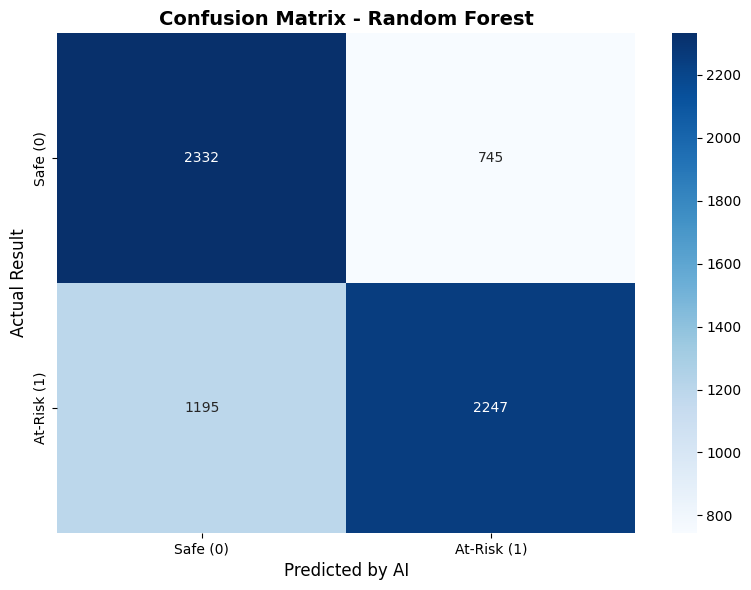

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


best_model_name = 'Random Forest'
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"\n=== Best Model: {best_model_name} ===")


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe (0)', 'At-Risk (1)'], 
            yticklabels=['Safe (0)', 'At-Risk (1)'])

plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted by AI', fontsize=12)
plt.ylabel('Actual Result', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import cross_val_score

print(f"Running Cross-Validation for {best_model_name}...")
print("This splits the data 5 different ways to ensure our accuracy isn't just luck.\n")


cv_scores = cross_val_score(best_model, X_encoded, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracies: {cv_scores.round(4)}")
print(f"Average Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")
print("\n✅ Cross-validation proves our model is stable and reliable!")

Running Cross-Validation for Random Forest...
This splits the data 5 different ways to ensure our accuracy isn't just luck.

Cross-Validation Accuracies: [0.6906 0.6079 0.5992 0.5037 0.6031]
Average Accuracy: 60.09% (+/- 5.93%)

✅ Cross-validation proves our model is stable and reliable!
